# Cluster patients into group based on their genes' expression data scRNA_2638cells_1838genes.csv

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn

np.set_printoptions(suppress = True)
pd.set_option('display.width', 1000)

In [4]:
genes = pd.read_csv('scRNA_2638cells_1838genes.csv')
genes

,index,TNFRSF4,CPSF3L,ATAD3C,C1orf86,RER1,TNFRSF25,TNFRSF9,CTNNBIP1,SRM,...,DSCR3,BRWD1,BACE2,SIK1,C21orf33,ICOSLG,SUMO3,SLC19A1,S100B,PRMT2
0,AAACATACAACCAC-1,-0.171470,-0.280812,-0.046677,-0.475169,-0.544024,4.928495,-0.038028,-0.280573,-0.341788,...,-0.226570,-0.236269,-0.102943,-0.222116,-0.312401,-0.121678,-0.521229,-0.098269,-0.209095,-0.531203
1,AAACATTGAGCTAC-1,-0.214582,-0.372653,-0.054804,-0.683391,0.633951,-0.334837,-0.045589,-0.498264,-0.541914,...,-0.317530,2.568865,0.007155,-0.445372,1.629285,-0.058662,-0.857164,-0.266844,-0.313146,-0.596654
2,AAACATTGATCAGC-1,-0.376887,-0.295084,-0.057528,-0.520972,1.332647,-0.309362,-0.103108,-0.272526,-0.500798,...,-0.302938,-0.239801,-0.071774,-0.297857,-0.410920,-0.070431,-0.590721,-0.158656,-0.170876,1.379000
3,AAACCGTGCTTCCG-1,-0.285241,-0.281735,-0.052227,-0.484929,1.572679,-0.271825,-0.074552,-0.258876,-0.416752,...,-0.262978,-0.231807,-0.093818,-0.247770,2.552078,-0.097402,1.631685,-0.119462,-0.179120,-0.505670
4,AAACCGTGTATGCG-1,-0.256483,-0.220394,-0.046800,-0.345859,-0.333409,-0.208122,-0.069514,5.806442,-0.283112,...,-0.202237,-0.176765,-0.167350,-0.098665,-0.275836,-0.139482,-0.310096,-0.006877,-0.109614,-0.461946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2633,TTTCGAACTCTCAT-1,-0.290368,2.638305,-0.054510,-0.554385,-0.666646,-0.301333,-0.074079,-0.334131,-0.478076,...,2.865903,-0.259984,-0.057421,-0.320982,-0.396917,-0.078147,1.232168,-0.174593,-0.216714,-0.529870
2634,TTTCTACTGAGGCA-1,-0.386343,2.652696,-0.058686,-0.545443,1.201865,-0.321670,-0.105418,-0.296857,1.803535,...,-0.314890,-0.249159,-0.058679,-0.324692,-0.427120,-0.062188,-0.630103,-0.178990,-0.181736,-0.502022
2635,TTTCTACTTCCTCG-1,-0.207090,-0.250464,-0.046397,-0.409737,2.193953,-0.221747,-0.051566,-0.198130,-0.307756,...,-0.212130,-0.206711,10.000000,-0.158643,3.308512,-0.132098,2.264174,-0.051144,-0.161064,2.041497
2636,TTTGCATGAGAGGC-1,-0.190328,-0.226334,-0.043999,-0.354661,-0.350005,-0.195177,-0.047832,-0.142079,-0.251677,...,-0.186529,-0.185312,-0.165108,-0.098862,-0.256393,-0.149789,-0.325824,-0.005918,-0.135213,-0.482111


In [26]:
genes.isnull().any()[genes.isnull().any()] #No Null values

Series([], dtype: bool)

# Use PCA to reduce original data's dimension, then cluster

In [88]:
from sklearn.decomposition import PCA

pca_genes = PCA(0.9).fit(genes.drop('index', axis = 1))

In [90]:
col_names = [f'PC_{i}' for i in range(pca_genes.n_components_)]

genes_reduce = pd.DataFrame(pca_genes.transform(genes.drop('index', axis = 1)), columns=col_names)
genes_reduce

,PC_0,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,...,PC_1015,PC_1016,PC_1017,PC_1018,PC_1019,PC_1020,PC_1021,PC_1022,PC_1023,PC_1024
0,-5.556221,-0.257725,0.186793,-2.800096,0.050725,-0.010710,0.560379,-3.071805,2.945072,-1.946769,...,0.296036,-0.367212,1.379289,-0.643706,-0.418068,0.801485,-0.200574,0.708739,0.685836,-0.954456
1,-7.209530,-7.481997,-0.162708,8.018516,-3.006618,-0.118060,2.389271,-1.063652,-0.655465,0.671243,...,0.609057,1.400248,0.526273,-1.314493,-0.215035,-0.303210,-1.194358,0.639087,-0.604965,-1.442754
2,-2.694437,1.583663,0.663121,-2.205642,1.789019,1.950147,-2.070497,-1.606437,0.911344,-1.386181,...,1.099070,0.119904,-0.074868,-0.253915,0.672784,0.697626,0.776529,-0.273320,-0.135303,-0.589199
3,10.143297,1.368529,-1.209824,0.700071,2.906166,0.036249,1.272863,0.387447,0.858386,0.004134,...,-0.129074,0.069711,-0.075926,0.459888,0.138551,0.423585,-0.725841,-0.337416,0.405054,0.570994
4,1.112816,8.152794,-1.332363,4.252489,-1.963183,-5.671660,0.372420,0.136135,-0.812767,-0.105279,...,-0.591736,0.636294,-0.398718,-0.801729,-0.788878,-0.397938,-0.335412,0.995773,-0.493764,-0.294775
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2633,9.601188,0.180183,-1.452580,0.237511,-5.028787,2.764367,1.264216,3.897561,0.976118,2.617135,...,-0.088371,-0.316441,0.315353,1.012248,-0.028763,-0.443983,-0.817154,-0.837006,0.531333,-0.170236
2634,-2.847882,-3.722203,0.217054,4.692720,0.254990,0.191907,0.682642,-0.280517,-2.262525,-5.913698,...,0.532063,1.099100,-0.041419,0.520327,-0.319446,0.613484,0.217705,-0.177911,-0.252009,-0.791590
2635,-0.785397,-6.718589,-1.598837,4.170281,0.784722,-1.120678,0.720844,1.615409,0.169155,0.838479,...,-0.007212,-0.336109,0.046993,-0.439005,0.351586,-0.626833,1.134429,1.959450,0.037344,-1.009866
2636,0.281271,-5.921856,-1.162880,7.345955,0.484283,0.413805,0.496881,-1.101033,-1.018055,-0.100580,...,0.856047,-0.044392,0.459502,-1.157827,0.473629,-0.014125,-1.070930,-0.340378,0.460979,-0.223489


In [105]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import MinMaxScaler
from imblearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

k_nums = range(2,16)

for k in k_nums:
    hierclust_pipe = Pipeline([
        ('MinMaxScaler', MinMaxScaler()),
        ('HierachichalClustering', AgglomerativeClustering(n_clusters = k))
    ])
    hierclust_pipe.fit(genes_reduce)
    labels = hierclust_pipe.named_steps['HierachichalClustering'].labels_
    print(f'Silhouette score for k = {k}: {silhouette_score(genes_reduce, labels)}')


print('\nChoose K = 2')

Silhouette score for k = 2: 0.007707891650132846
Silhouette score for k = 3: 0.0036686518888797586
Silhouette score for k = 4: 0.00437014828795073
Silhouette score for k = 5: 0.003462270048006356
Silhouette score for k = 6: -0.003434594824995949
Silhouette score for k = 7: -0.0033257164163731606
Silhouette score for k = 8: -0.0033867618435237407
Silhouette score for k = 9: -0.00313163258080405
Silhouette score for k = 10: -0.003116387281489455
Silhouette score for k = 11: -0.00299787070577363
Silhouette score for k = 12: -0.0028652555249088782
Silhouette score for k = 13: -0.002722924846126248
Silhouette score for k = 14: -0.0024896962885037387
Silhouette score for k = 15: -0.0038805168279217243

Choose K = 2


In [377]:
hierclust_pipe = Pipeline([
    ('MinMaxScaler', MinMaxScaler()),
    ('HierachichalClustering', AgglomerativeClustering(n_clusters = 2, compute_distances=True))
])
hierclust_pipe.fit(genes_reduce)
labels = hierclust_pipe.named_steps['HierachichalClustering'].labels_

genes['Group'] = labels
genes

,index,TNFRSF4,CPSF3L,ATAD3C,C1orf86,RER1,TNFRSF25,TNFRSF9,CTNNBIP1,SRM,...,BRWD1,BACE2,SIK1,C21orf33,ICOSLG,SUMO3,SLC19A1,S100B,PRMT2,Group
0,AAACATACAACCAC-1,-0.171470,-0.280812,-0.046677,-0.475169,-0.544024,4.928495,-0.038028,-0.280573,-0.341788,...,-0.236269,-0.102943,-0.222116,-0.312401,-0.121678,-0.521229,-0.098269,-0.209095,-0.531203,1
1,AAACATTGAGCTAC-1,-0.214582,-0.372653,-0.054804,-0.683391,0.633951,-0.334837,-0.045589,-0.498264,-0.541914,...,2.568865,0.007155,-0.445372,1.629285,-0.058662,-0.857164,-0.266844,-0.313146,-0.596654,0
2,AAACATTGATCAGC-1,-0.376887,-0.295084,-0.057528,-0.520972,1.332647,-0.309362,-0.103108,-0.272526,-0.500798,...,-0.239801,-0.071774,-0.297857,-0.410920,-0.070431,-0.590721,-0.158656,-0.170876,1.379000,0
3,AAACCGTGCTTCCG-1,-0.285241,-0.281735,-0.052227,-0.484929,1.572679,-0.271825,-0.074552,-0.258876,-0.416752,...,-0.231807,-0.093818,-0.247770,2.552078,-0.097402,1.631685,-0.119462,-0.179120,-0.505670,1
4,AAACCGTGTATGCG-1,-0.256483,-0.220394,-0.046800,-0.345859,-0.333409,-0.208122,-0.069514,5.806442,-0.283112,...,-0.176765,-0.167350,-0.098665,-0.275836,-0.139482,-0.310096,-0.006877,-0.109614,-0.461946,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2633,TTTCGAACTCTCAT-1,-0.290368,2.638305,-0.054510,-0.554385,-0.666646,-0.301333,-0.074079,-0.334131,-0.478076,...,-0.259984,-0.057421,-0.320982,-0.396917,-0.078147,1.232168,-0.174593,-0.216714,-0.529870,0
2634,TTTCTACTGAGGCA-1,-0.386343,2.652696,-0.058686,-0.545443,1.201865,-0.321670,-0.105418,-0.296857,1.803535,...,-0.249159,-0.058679,-0.324692,-0.427120,-0.062188,-0.630103,-0.178990,-0.181736,-0.502022,0
2635,TTTCTACTTCCTCG-1,-0.207090,-0.250464,-0.046397,-0.409737,2.193953,-0.221747,-0.051566,-0.198130,-0.307756,...,-0.206711,10.000000,-0.158643,3.308512,-0.132098,2.264174,-0.051144,-0.161064,2.041497,0
2636,TTTGCATGAGAGGC-1,-0.190328,-0.226334,-0.043999,-0.354661,-0.350005,-0.195177,-0.047832,-0.142079,-0.251677,...,-0.185312,-0.165108,-0.098862,-0.256393,-0.149789,-0.325824,-0.005918,-0.135213,-0.482111,0


# Use selectKbest to choose 3 most significant genes

In [379]:
from sklearn.feature_selection import SelectKBest, f_classif

k_best = SelectKBest(k='all', score_func=f_classif).fit(genes.drop(['index', 'Group'], axis = 1), genes['Group'])

#Create a dataframe Feature_name : Score
df_k_best_score = pd.DataFrame({
    'Feature_name':genes.drop(['index', 'Group'], axis = 1).columns,
    'Score':k_best.scores_
})

#Sort in descending order
df_k_best_score = df_k_best_score.sort_values('Score', ascending=False).reset_index(drop = True)

df_k_best_score['Cumulative_Percentage'] = np.cumsum(df_k_best_score['Score']) / df_k_best_score['Score'].sum()

df_k_best_score[df_k_best_score['Cumulative_Percentage'] <= 0.9]

,Feature_name,Score,Cumulative_Percentage
0,TYROBP,178.055817,0.015340
1,HLA-DRB1,172.296457,0.030184
2,FCER1G,171.489534,0.044958
3,HLA-DPA1,161.383875,0.058862
4,HLA-DPB1,160.943454,0.072727
...,...,...,...
646,C9orf37,3.734020,0.898734
647,CORO1B,3.670333,0.899051
648,SPG7,3.659817,0.899366
649,PGM1,3.659599,0.899681


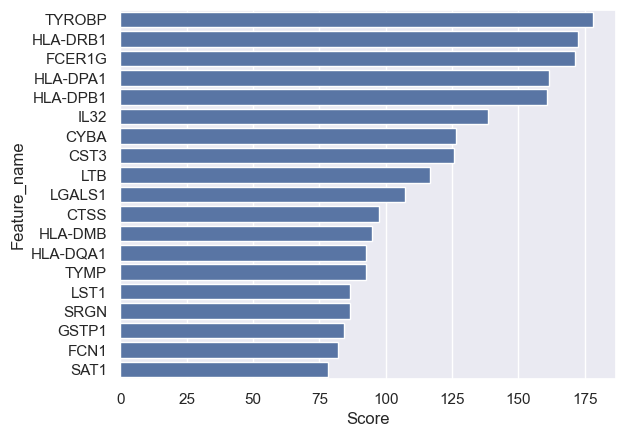

In [351]:
sbn.barplot(data = df_k_best_score[df_k_best_score['Cumulative_Percentage'] <= 0.2],
           y = 'Feature_name',
           x = 'Score')
plt.show()

# Choose 3 genes 'TYROBP', 'HLA-DRB1' and 'FCER1G'

## TYROBP: 
+ encodes protein tyrosine kinase-binding protein
+ a transmembrane signaling polypeptide
+ Pathological mutations of the TYROBP gene cause "polycystic lipomembranous osteodysplasia with sclerosing leukoencephalopathy 1", a condition presenting as early-onset dementia

## HLA-DRB1:
+ The HLA-DRB1 gene is part of a family of genes called the human leukocyte antigen (HLA) complex
+ The HLA complex helps the immune system distinguish the body's own proteins from proteins made by foreign invaders such as viruses and bacteria

## FCER1G:
+ encodes Fc fragment of IgE, high affinity I, receptor for; gamma polypeptide is gamma chain of high affinity IgE receptor
+ The high affinity IgE receptor, FcεRI, is a key molecule involved in allergic reactions

In [354]:
genes_3 = genes[['index', 'TYROBP', 'HLA-DRB1', 'FCER1G', 'Group']]

hierclust_pipe = Pipeline([
    ('MinMaxScaler', MinMaxScaler()),
    ('HierachichalClustering', AgglomerativeClustering(n_clusters = 3, compute_distances=True))
])
hierclust_pipe.fit(genes_3.drop(['index', 'Group'], axis = 1))
labels = hierclust_pipe.named_steps['HierachichalClustering'].labels_

print(silhouette_score(genes_3.drop(['index', 'Group'], axis = 1), labels))

genes_3['Group'] = labels

genes_3

0.5298663699181229


C:\Users\Admin\AppData\Local\Temp\ipykernel_708\1035733453.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genes_3['Group'] = labels


,index,TYROBP,HLA-DRB1,FCER1G,Group
0,AAACATACAACCAC-1,-0.947659,-1.030499,-0.936455,2
1,AAACATTGAGCTAC-1,-1.649799,0.465531,-1.794215,1
2,AAACATTGATCAGC-1,-0.751388,-0.862629,-0.715626,2
3,AAACCGTGCTTCCG-1,1.594738,1.723380,1.728247,0
4,AAACCGTGTATGCG-1,1.183545,-0.462540,1.631157,0
...,...,...,...,...,...
2633,TTTCGAACTCTCAT-1,1.273566,0.792001,0.378498,0
2634,TTTCTACTGAGGCA-1,0.016754,0.975458,-0.807261,1
2635,TTTCTACTTCCTCG-1,-0.639010,1.020995,-0.564151,1
2636,TTTGCATGAGAGGC-1,-0.462880,2.121530,-0.348465,1


# Draw dedogram and clustered_heatmap

In [357]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

def plot_dendrogram(model, **kwargs):
    """
    Plots a dendrogram from an AgglomerativeClustering model.

    Args:
        model: AgglomerativeClustering model.
        **kwargs: Keyword arguments to pass to scipy.cluster.hierarchy.dendrogram.
    """
    # Create linkage matrix from the model's children.
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # Leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram.
    dendrogram(linkage_matrix, **kwargs)
    plt.show()


def plot_clustered_heatmap(data, model, title="Clustered Heatmap"):
    """
    Plots a clustered heatmap from AgglomerativeClustering outputs.

    Args:
        data: The original data (DataFrame or NumPy array).
        model: Fitted AgglomerativeClustering model.
        title: Title of the plot.
    """

    # Create linkage matrix
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Reorder the data based on clustering
    if isinstance(data, pd.DataFrame):
        ordered_indices = model.labels_
        ordered_data = data.iloc[np.argsort(ordered_indices)]
    else:
        ordered_indices = model.labels_
        ordered_data = data[np.argsort(ordered_indices)]

    # Plot the clustered heatmap
    fig = sbn.clustermap(ordered_data, row_linkage=linkage_matrix, col_cluster=False, figsize=(10, 8), cmap="viridis", cbar_pos=(0.02, 0.8, 0.03, 0.15))
    fig.ax_heatmap.set_title(title)
    plt.show()

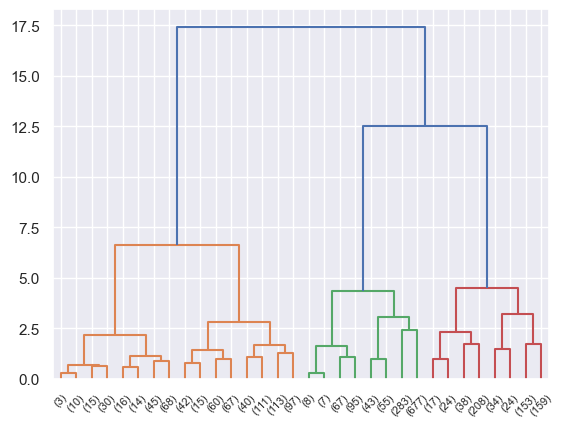

In [359]:
plot_dendrogram(hierclust_pipe.named_steps['HierachichalClustering'], truncate_mode = 'level', p = 4)

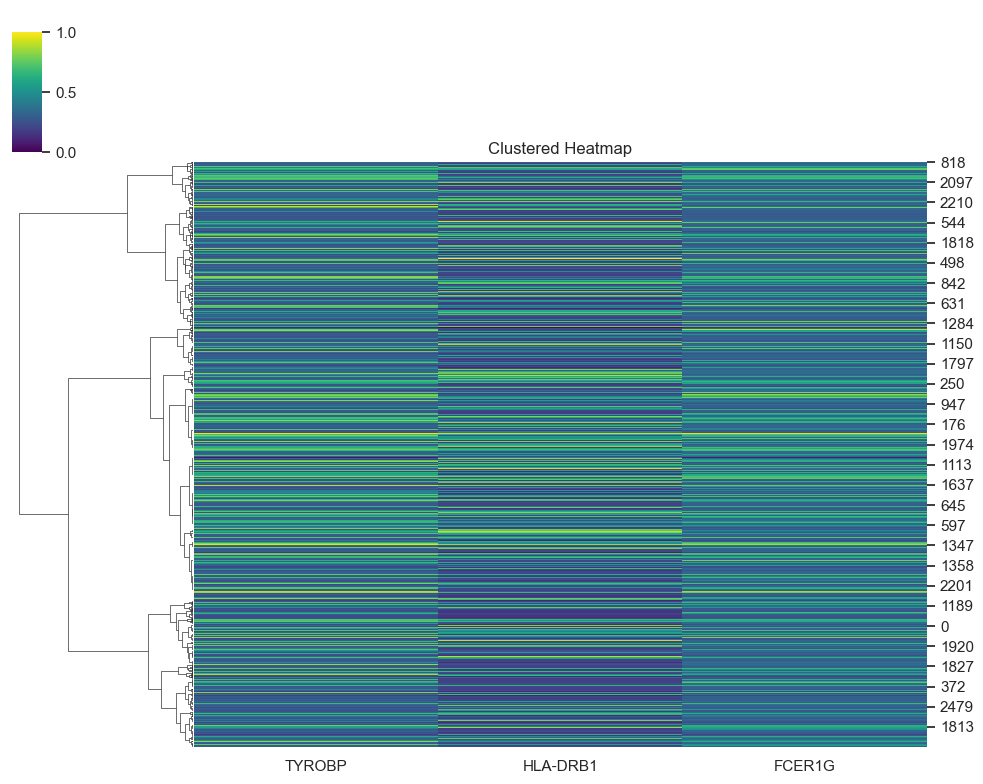

In [361]:
genes_3_plot = hierclust_pipe.named_steps['MinMaxScaler'].transform(genes_3.drop(['index', 'Group'], axis = 1))
genes_3_plot = pd.DataFrame(genes_3_plot, columns = ['TYROBP', 'HLA-DRB1', 'FCER1G'])

plot_clustered_heatmap(genes_3_plot, hierclust_pipe.named_steps['HierachichalClustering'])

# Draw scatterplot

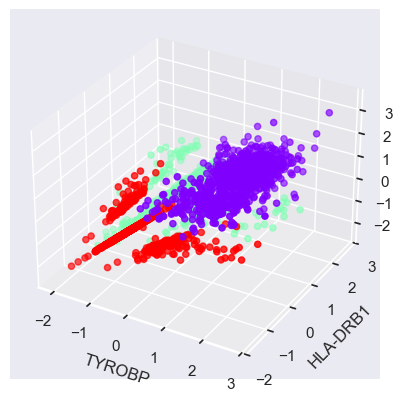

In [364]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')

ax.scatter(xs = genes_3['TYROBP'], ys = genes_3['HLA-DRB1'], zs = genes_3['FCER1G'], c = genes_3['Group'],
          cmap = 'rainbow')
ax.set_xlabel('TYROBP')
ax.set_ylabel('HLA-DRB1')
ax.set_zlabel('FCER1G')
plt.show()

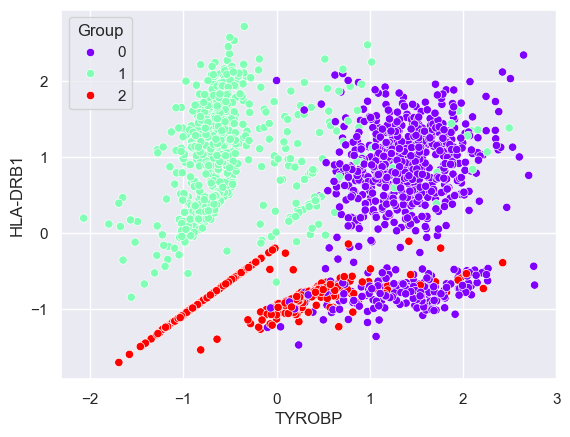

In [366]:
sbn.set_theme(style='darkgrid')
sbn.scatterplot(data = genes_3, x = 'TYROBP', y = 'HLA-DRB1', hue = 'Group', palette = 'rainbow')
plt.show()

Number of numeric fields: 3

All numeric fields: ['TYROBP', 'HLA-DRB1', 'FCER1G']



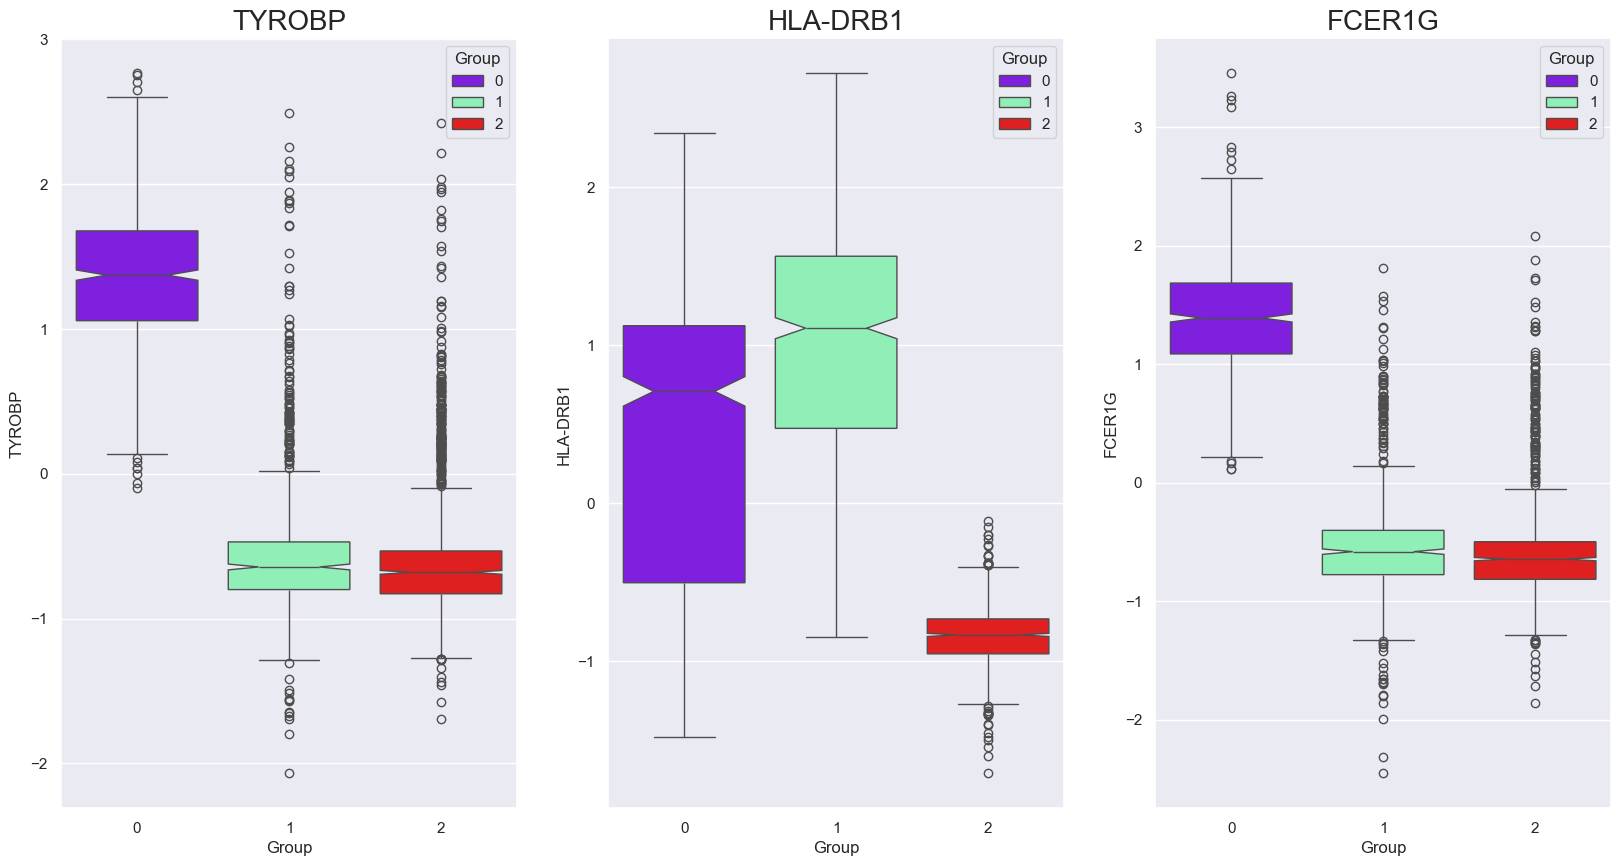

In [368]:
data_group = genes_3.copy()
numeric_cols = ['TYROBP', 'HLA-DRB1', 'FCER1G']

##### Function building ##############

def boxplot_numeric(df, numeric_cols, figsize=(20, 10), groups = None):
    col = 3
    if (len(numeric_cols) % 3) == 0:
        row = len(numeric_cols) // 3
    else:
        row = (len(numeric_cols) // 3) + 1
    '''
    numeric_cols: list các tên cột biến định lượng
    row: số lượng dòng trong lưới đồ thị
    col: số lượng cột trong lưới đồ thị
    figsize: kích thước biểu đồ
    groups: tên cột chứa biến phân nhóm như 'Group' hoặc 'Class' hoặc 'Label'
    '''
    print(f'Number of numeric fields: {len(numeric_cols)}')
    print()
    print(f'All numeric fields: {numeric_cols}')
    print()
    plt.figure(figsize = figsize)
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0.3)
    for i in range(1, len(numeric_cols)+1, 1):
      try:
        plt.subplot(row, col, i)
        sbn.boxplot(data = df, x = groups, y = numeric_cols[i-1], notch = True, hue = groups, palette = 'rainbow')
        plt.title(numeric_cols[i-1], size = 20)
      except:
        print('Error {}'.format(numeric_cols[i-1]))
        break
    plt.show()

## Draw
sbn.set_theme(style ='darkgrid')
boxplot_numeric(data_group, numeric_cols, groups = data_group.iloc[:,-1])

# Report clustering results

## Patient Group 0:
+ TYROBP: high expression
+ HLA-DRB1: medium expression
+ FCER1G: high expression

## Patient Group 1:
+ TYROBP: low expression
+ HLA-DRB1: high expression
+ FCER1G: low expression

## Patient Group 2:
+ TYROBP: low expression
+ HLA-DRB1: low expression
+ FCER1G: low expression